# Blinkit Retail Sales Analysis

### Exploratory analysis of product performance and outlet-level sales patterns

**Project objective:** Analyse item-outlet sales data to understand category contribution, fat-content mix, outlet-tier performance, establishment-year patterns, and outlet-size distribution.

**Tools used:** Python, Pandas, Matplotlib, Seaborn, and Jupyter Notebook.

**Business context:** The analysis is designed as a portfolio case study that converts raw retail data into clear, decision-oriented charts and observations.

## Analysis Roadmap

The notebook follows a simple workflow: load and inspect the dataset, review missing values, standardise inconsistent labels, calculate total sales, and compare sales across product and outlet dimensions. The charts are descriptive and should be interpreted together with the data-quality notes.

In [1]:
import pandas as pd
d=pd.read_csv("blinkit_data.csv")

In [2]:
d.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [3]:
d.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [4]:
d.dtypes

Item Fat Content                 str
Item Identifier                  str
Item Type                        str
Outlet Establishment Year      int64
Outlet Identifier                str
Outlet Location Type             str
Outlet Size                      str
Outlet Type                      str
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [5]:
d.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')

In [6]:
d.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

## Visual 1 — Product Attribute Profile

**What this view shows:** The grouped table compares average item visibility and average item weight by fat-content segment. The pie chart uses the one-dimensional **average item visibility** measure so the chart remains mathematically valid; average item weight is retained in the table for comparison.

**Why it matters:** This is a descriptive product-attribute view. It helps compare how product visibility and weight are distributed across standardised fat-content groups.

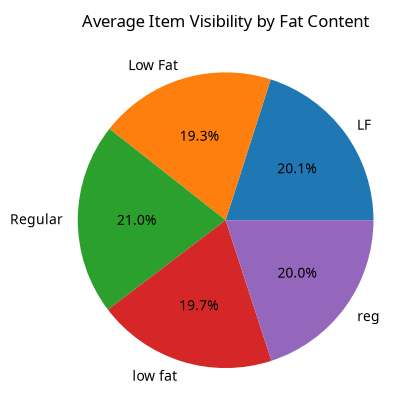

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
gb = d.groupby('Item Fat Content').agg({
    'Item Visibility': 'mean',
    'Item Weight': 'mean'
})
gb
plt.pie(gb['Item Visibility'], labels=gb.index, autopct='%.1f%%')
plt.title('Average Item Visibility by Fat Content')
plt.show()

In [8]:
d.columns=d.columns.str.replace(" ","_")
d.columns=d.columns.str.lower()

In [9]:
d.tail()

,item_fat_content,item_identifier,item_type,outlet_establishment_year,outlet_identifier,outlet_location_type,outlet_size,outlet_type,item_visibility,item_weight,sales,rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


In [10]:
d['item_fat_content'].unique()

<StringArray>
['Regular', 'Low Fat', 'low fat', 'LF', 'reg']
Length: 5, dtype: str

In [11]:
d['item_fat_content']=d['item_fat_content'].replace({'LF':'Low Fat','reg':'Regular','low fat':'Low Fat'})

In [12]:
total_sales=d['sales'].sum()
print(total_sales)

1201681.4808


## Visual 2 — Sales Mix by Fat Content

**What this chart shows:** Total observed sales are grouped into the standardised `Regular` and `Low Fat` segments.

**Why it matters:** The comparison highlights product-mix contribution. It does not prove that fat content causes higher sales, because pricing, category, outlet mix, and other factors are not controlled.

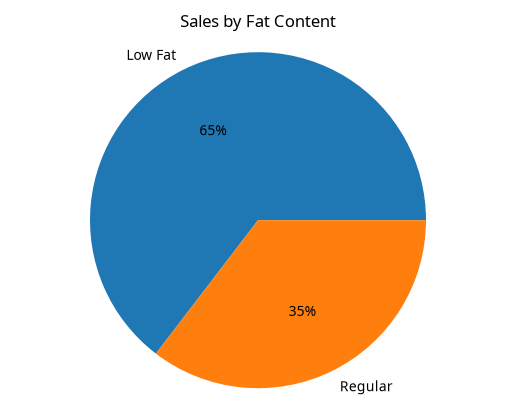

In [13]:
gb=d.groupby('item_fat_content').agg({'sales':'sum'})
plt.pie(gb['sales'],labels=gb.index,autopct='%.0f%%')
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

## Visual 3 — Sales by Item Category

**What this chart shows:** Each bar represents the total sales contribution of one item category, ranked from highest to lowest.

**Why it matters:** Category ranking helps identify leading assortment groups and categories that may need further review. A high total can reflect both strong performance and a larger number of records.

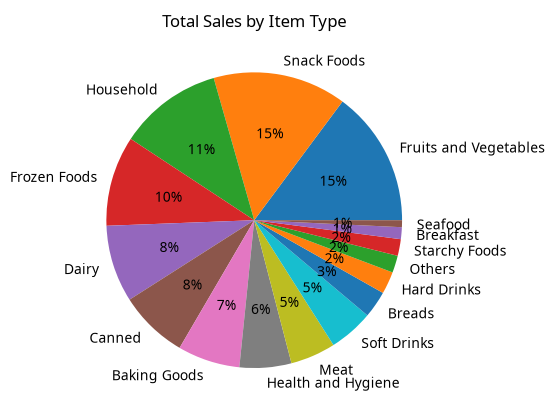

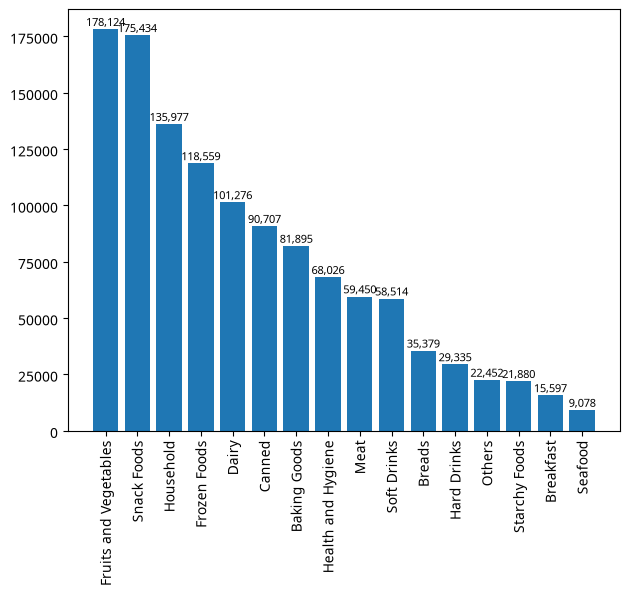

In [14]:
gb = d.groupby('item_type').agg({'sales':'sum'}).sort_values('sales', ascending=False)

plt.pie(gb['sales'], labels=gb.index, autopct='%.0f%%')
plt.title('Total Sales by Item Type')
plt.show()

bars=plt.bar(gb.index, gb['sales'])
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{bar.get_height():,.0f}',ha='center',va='bottom',fontsize=8)


plt.tight_layout()
plt.xticks(rotation=90)
plt.show()


## Visual 4 — Fat Content by Outlet Location Tier

**What this chart shows:** Regular and Low Fat sales are compared within each outlet location tier.

**Why it matters:** The grouped view separates overall tier scale from product-mix composition and supports more focused outlet-level follow-up.

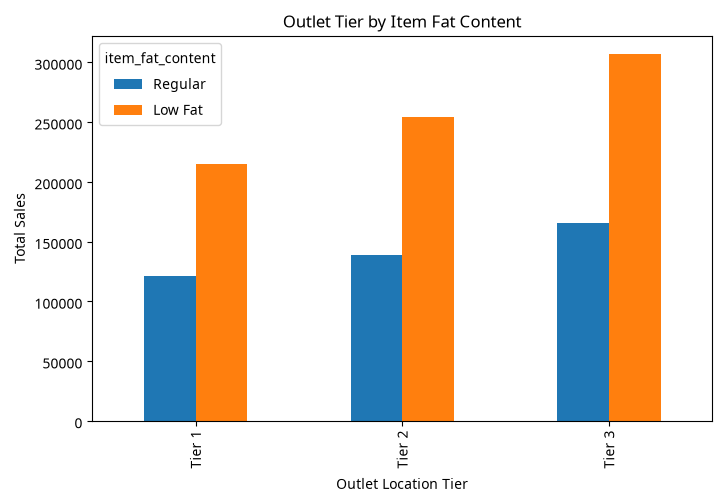

In [15]:
grouped = d.groupby(
    ['outlet_location_type', 'item_fat_content']
).agg({'sales':'sum'}).unstack()

grouped = grouped['sales'][['Regular', 'Low Fat']]

grouped.plot(kind='bar', figsize=(8,5), title='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.show()


## Visual 5 — Sales by Outlet Establishment Year

**What this chart shows:** Total sales are aggregated by outlet establishment year. This is a cohort view, not a daily or monthly sales trend.

**Why it matters:** Comparing cohorts can show where sales are concentrated across outlet vintages, while avoiding an unsupported assumption that older outlets perform better.

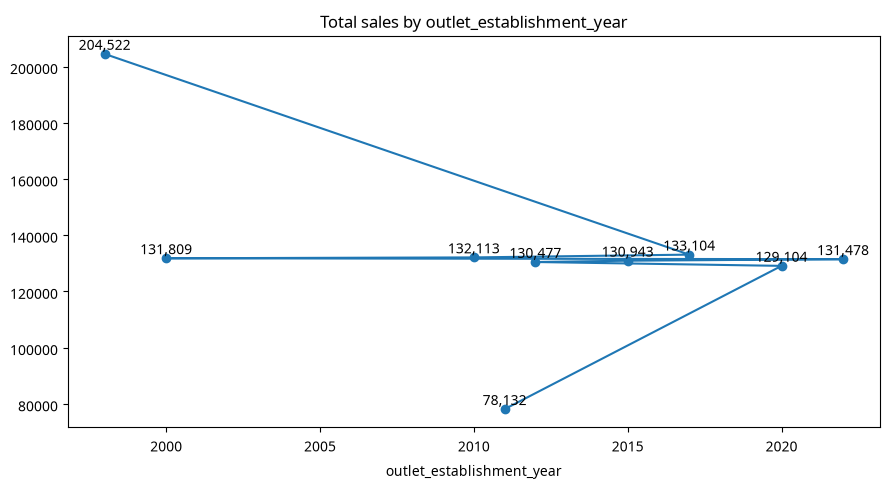

In [16]:
plt.figure(figsize=(9,5))
gb=d.groupby('outlet_establishment_year').agg({'sales':'sum'}).sort_values('sales',ascending=False)
plt.plot(gb.index,gb['sales'],marker='o',linestyle='-')

plt.title('Total sales by outlet_establishment_year')
plt.xlabel('outlet_establishment_year')

for x,y in zip(gb.index,gb['sales']):
    plt.text(x,y,f'{y:,.0f}',ha='center',va='bottom')

plt.tight_layout()


plt.show()

## Visual 6 — Sales by Outlet Size

**What this chart shows:** Total observed sales are compared across outlet-size groups.

**Why it matters:** Outlet size provides operational context, but total sales alone should not be treated as efficiency. The additional normalized analysis below compares average sales per record.

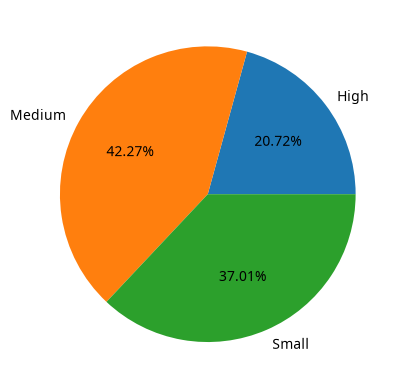

In [17]:
gb=d.groupby('outlet_size').agg({'sales':'sum'})

plt.pie(gb['sales'],labels=gb.index,autopct='%1.2f%%')
plt.show()

## Visual 7 — Sales by Outlet Location Tier

**What this chart shows:** Total sales are compared across Tier 1, Tier 2, and Tier 3 location groups.

**Why it matters:** This identifies where sales are concentrated in the extract and creates a starting point for deeper outlet-type and category drill-down.

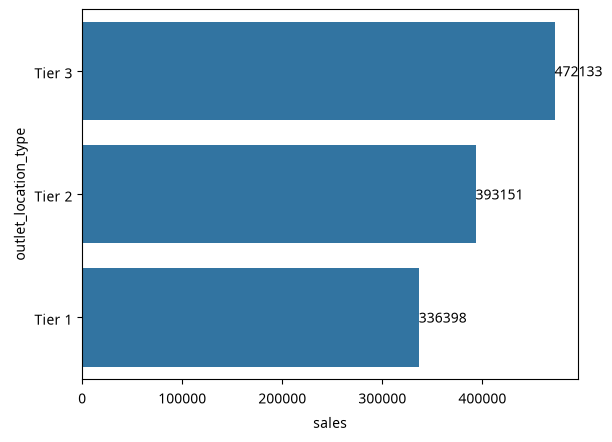

In [18]:
gb=d.groupby('outlet_location_type').agg({'sales':'sum'}).sort_values('sales',ascending=False)
ax=sns.barplot(x='sales',y='outlet_location_type',data=gb)
ax.bar_label(ax.containers[0])
plt.show()

## Focused Business Analysis

The original exploratory charts answer **what happened**. The next three cells add a compact second layer: normalized outlet performance, category contribution, and correlation checks. These additions are intentionally limited so the original learning flow remains easy to follow.

### Visual 8 — Outlet Performance: Scale vs. Efficiency

**Definition:** Total sales measures outlet-format scale, while average sales per record provides a simple normalized comparison.

**Why it matters:** Comparing both measures helps avoid calling a segment efficient merely because it has more records in the extract.

In [19]:
outlet_efficiency = (
    d.groupby('outlet_type')
     .agg(total_sales=('sales', 'sum'), average_sales=('sales', 'mean'), records=('sales', 'size'))
     .assign(revenue_share_pct=lambda x: x['total_sales'] / total_sales * 100)
     .sort_values('total_sales', ascending=False)
)
outlet_efficiency.round({'total_sales': 2, 'average_sales': 2, 'revenue_share_pct': 2})

,total_sales,average_sales,records,revenue_share_pct
outlet_type,,,,
Supermarket Type1,787549.89,141.21,5577,65.54
Grocery Store,151939.15,140.29,1083,12.64
Supermarket Type2,131477.77,141.68,928,10.94
Supermarket Type3,130714.67,139.80,935,10.88


### Visual 9 — Category Contribution and Concentration

**Definition:** Category contribution expresses each item category's sales as a percentage of total observed sales. The cumulative share provides a simple Pareto-style concentration check.

**Why it matters:** This indicates whether a small number of categories account for a large share of observed sales, which can guide assortment prioritisation.

In [20]:
category_performance = (
    d.groupby('item_type')
     .agg(total_sales=('sales', 'sum'), average_sales=('sales', 'mean'), records=('sales', 'size'))
     .assign(revenue_share_pct=lambda x: x['total_sales'] / total_sales * 100)
     .sort_values('total_sales', ascending=False)
)
category_performance['cumulative_share_pct'] = category_performance['revenue_share_pct'].cumsum()
category_performance.round({'total_sales': 2, 'average_sales': 2, 'revenue_share_pct': 2, 'cumulative_share_pct': 2})

,total_sales,average_sales,records,revenue_share_pct,cumulative_share_pct
item_type,,,,,
Fruits and Vegetables,178124.08,144.58,1232,14.82,14.82
Snack Foods,175433.92,146.19,1200,14.60,29.42
Household,135976.53,149.42,910,11.32,40.74
Frozen Foods,118558.88,138.50,856,9.87,50.60
Dairy,101276.46,148.50,682,8.43,59.03
Canned,90706.73,139.76,649,7.55,66.58
Baking Goods,81894.74,126.38,648,6.82,73.39
Health and Hygiene,68025.84,130.82,520,5.66,79.06
Meat,59449.86,139.88,425,4.95,84.00


### Visual 10 — Correlation Check

**Definition:** The correlation matrix measures linear association among available numeric fields such as sales, rating, visibility, weight, and establishment year.

**Interpretation rule:** Correlation can identify patterns worth investigating, but it cannot establish causation. Missing item-weight values are handled pairwise by Pandas rather than silently imputed.

In [21]:
numeric_relationships = d[['sales', 'rating', 'item_visibility', 'item_weight', 'outlet_establishment_year']].corr()
numeric_relationships.round(3)

,sales,rating,item_visibility,item_weight,outlet_establishment_year
sales,1.000,0.011,-0.001,0.027,0.005
rating,0.011,1.000,0.001,0.003,0.004
item_visibility,-0.001,0.001,1.000,-0.014,-0.075
item_weight,0.027,0.003,-0.014,1.000,-0.012
outlet_establishment_year,0.005,0.004,-0.075,-0.012,1.000


## Data-Driven Takeaways and Recommendations

The final cell turns the calculated tables into concise, reproducible talking points. Recommendations are deliberately framed as areas for management investigation rather than unsupported causal claims.

In [22]:
top_outlet = outlet_efficiency['total_sales'].idxmax()
best_avg_outlet = outlet_efficiency['average_sales'].idxmax()
top_category = category_performance['total_sales'].idxmax()
bottom_category = category_performance['total_sales'].idxmin()

print(f"1. Scale leader: {top_outlet} contributes the highest total sales in the extract.")
print(f"2. Normalized leader: {best_avg_outlet} has the highest average sales per record among outlet formats.")
print(f"3. Category priority: {top_category} is the leading category; {bottom_category} is the lowest by total observed sales.")
print("4. Action: investigate the scale-versus-efficiency gap before replicating an outlet format.")
print("5. Action: review lower-contribution categories by outlet type, location tier, visibility, and rating.")
print("6. Caution: treat correlation as a screening signal, not proof of causation.")

1. Scale leader: Supermarket Type1 contributes the highest total sales in the extract.
2. Normalized leader: Supermarket Type2 has the highest average sales per record among outlet formats.
3. Category priority: Fruits and Vegetables is the leading category; Seafood is the lowest by total observed sales.
4. Action: investigate the scale-versus-efficiency gap before replicating an outlet format.
5. Action: review lower-contribution categories by outlet type, location tier, visibility, and rating.
6. Caution: treat correlation as a screening signal, not proof of causation.


## Limitations

This is an educational item-outlet sales extract rather than a live internal Blinkit reporting feed. It does not contain cost, profit, orders over time, customer-level behaviour, delivery metrics, or causal experimental data. Total sales should not be interpreted as profit, and all conclusions should be read alongside the documented missing item-weight values.